# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"

In [8]:
pokemon_df = pd.read_csv(fp)
pokemon_df.drop(columns=['#'], inplace=True)
pokemon_df.head()


,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

Text(0.5, 1.02, 'Attack vs. Defense for all Pokemon')

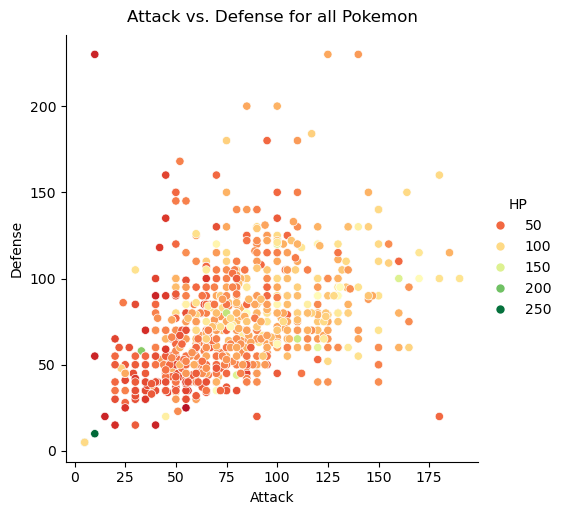

In [16]:
g = sns.relplot(data=pokemon_df, x='Attack', y='Defense', hue='HP', palette='RdYlGn')
g.figure.suptitle("Attack vs. Defense for all Pokemon", y=1.02)

### From the plot, I observed....
Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values as observed by the large quantity of yellow as you increase the attack and defense. However, there are outliers, such as the dark green with a very low attack and defense.

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

Text(0.5, 1.02, 'Attack vs total for all Pokemon')

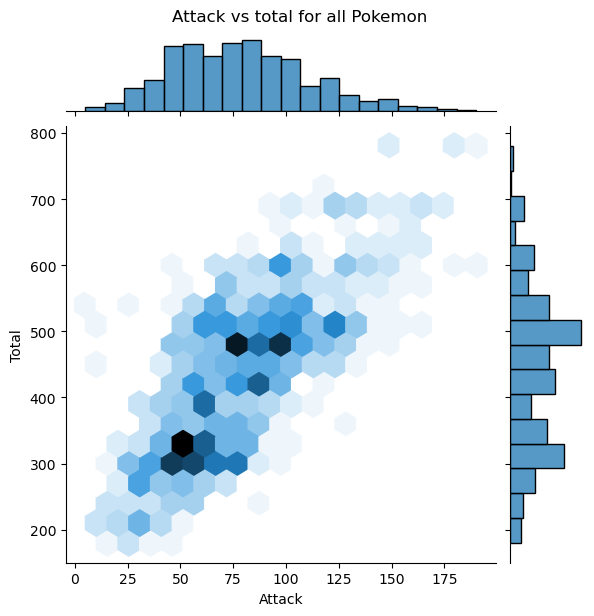

In [17]:
g = sns.jointplot(data=pokemon_df, x='Attack', y='Total', kind="hex")
g.figure.suptitle("Attack vs total for all Pokemon", y=1.02)

From the plot, I observed....

Attack and total have about a linear relationship with a pretty large slope (m > 2). That is, for a small change in the attack the other attibutes of the pokemon also increase, which makes sense. As for the distributions, it looks like both are slightly multimodal.

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

order1 = pokemon_df['Type 1'].value_counts().index
sns.countplot(data=pokemon_df, y='Type 1', order=order1, color='red', ax=axes[0])
axes[0].set_title("Count of Pokemon by Type 1")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Type 1")

order2 = pokemon_df['Type 2'].value_counts().index
sns.countplot(data=pokemon_df, y='Type 2', order=order2, color='blue', ax=axes[1])
axes[1].set_title("Count of Pokemon by Type 2")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Type 2")

plt.tight_layout()
plt.show()

### From the plots, I observed....
For **Type 1**, Water is the most common primary type by a wide margin, followed by Normal and Grass. The rarest Type 1 types are Flying and Fairy, which have very few Pokemon with those as their primary type.

For **Type 2**, Flying is the most common secondary type, followed by Ground and Poison. The rarest Type 2 types include Ice and Electric. A large portion of Pokemon also have no secondary type at all (NaN values are excluded from the plot).

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

## Q4: Which Type 1 has the highest median Attack?
Using a horizontal boxplot, compare the Attack distributions across all primary Pokemon types, sorted by median Attack from highest to lowest.

## Q5: How does Speed differ between Legendary and non-Legendary Pokemon?
Using a violin plot, visualize the full Speed distribution for Legendary vs. non-Legendary Pokemon to see if Legendary Pokemon tend to be faster.

## Q6: How correlated are the numeric combat stats?
Using a heatmap, display the pairwise Pearson correlations between HP, Attack, Defense, Sp. Atk, Sp. Def, Speed, and Total.

C:\Users\alex\AppData\Local\Temp\ipykernel_12612\402707265.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pokemon_df, y='Type 1', x='Attack', order=order, palette='Reds')


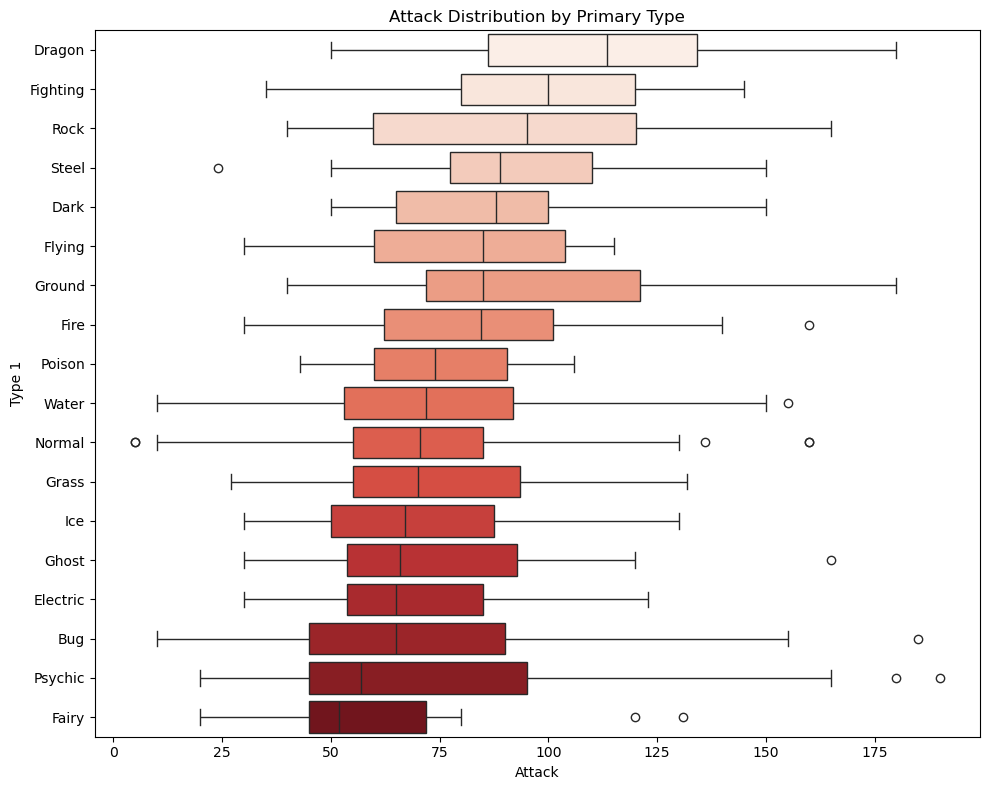

In [7]:
order = pokemon_df.groupby('Type 1')['Attack'].median().sort_values(ascending=False).index
plt.figure(figsize=(10, 8))
sns.boxplot(data=pokemon_df, y='Type 1', x='Attack', order=order, palette='Reds')
plt.title("Attack Distribution by Primary Type")
plt.tight_layout()
plt.show()

### From the plot, I observed....
Dragon and Fighting types have the highest median Attack among all primary types, while Bug and Poison types sit at the lower end. Most types show fairly wide interquartile ranges, meaning individual Pokemon within a type can vary considerably in Attack. Dragon types also have the most outliers toward the high end, reflecting a few extremely powerful Dragon-type Pokemon.

C:\Users\alex\AppData\Local\Temp\ipykernel_12612\1730388979.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=pokemon_df, x='Legendary', y='Speed', palette='Set2')


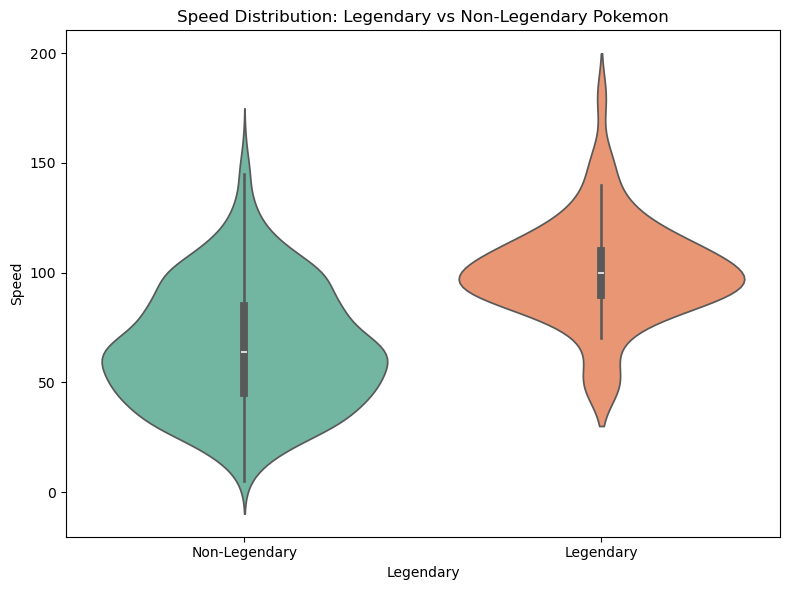

In [8]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=pokemon_df, x='Legendary', y='Speed', palette='Set2')
plt.title("Speed Distribution: Legendary vs Non-Legendary Pokemon")
plt.xticks([0, 1], ['Non-Legendary', 'Legendary'])
plt.tight_layout()
plt.show()

### From the plot, I observed....
Legendary Pokemon have a noticeably higher median Speed than non-Legendary Pokemon. The Legendary violin is wider at higher Speed values, indicating that many Legendary Pokemon cluster toward the faster end of the spectrum. Non-Legendary Pokemon show a broader, more symmetric distribution with the bulk of the mass concentrated around the 50–80 range. The gap in medians confirms that speed is one characteristic that tends to distinguish Legendary Pokemon from the rest.

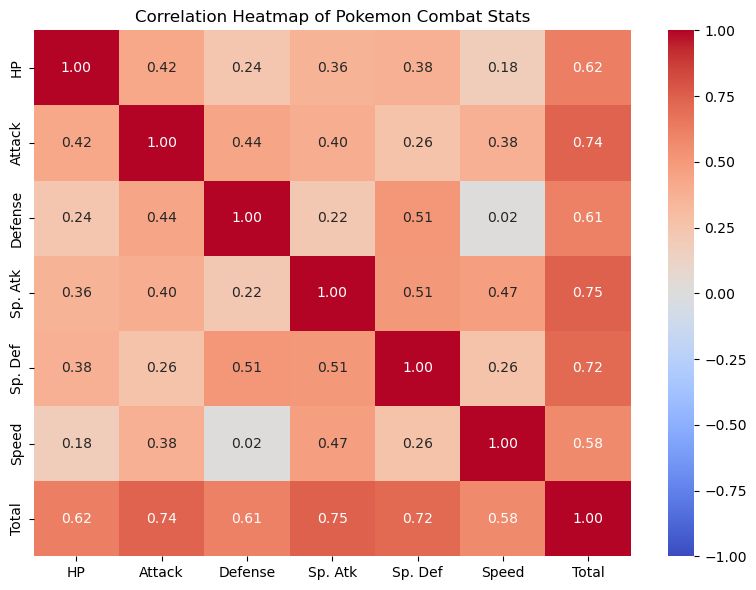

In [9]:
stats_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Total']
corr = pokemon_df[stats_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Pokemon Combat Stats")
plt.tight_layout()
plt.show()

### From the plot, I observed....
`Total` is strongly positively correlated with every individual stat (all values above 0.60), which makes sense since `Total` is defined as the sum of the other stats. Among the individual combat stats, `Sp. Atk` and `Sp. Def` show the highest mutual correlation (~0.50), suggesting that Pokemon with strong special offense also tend to have strong special defense. `Attack` and `Defense` also have a moderate positive correlation (~0.44). Interestingly, `Speed` has weaker correlations with the defensive stats (`HP`, `Defense`, `Sp. Def`) compared to the offensive ones, implying that fast Pokemon are not necessarily more durable.